# Electricity Demand Forecasting with XGBoost and LSTM

## Project overview
In this project, I investigate whether a deep-learning model can improve next-day electricity-demand forecasts compared with gradient-boosted trees and a weekly seasonal baseline.

My forecasting task is to predict the next 24 hourly readings at midnight, using the previous 168 hours of demand and calendar information known in advance. I evaluate every model on the same forecast dates.

**Research question:** Does an LSTM improve forecast accuracy enough to justify its additional complexity and training time?

I use one customer to keep the experiment manageable. My conclusions will therefore concern this customer and evaluation period, rather than electricity forecasting in general.

## Environment
I run the notebook from top to bottom in Kaggle with Internet enabled for the initial download. Under **Settings → Accelerator**, I select an available GPU. The LSTM uses a GPU automatically when PyTorch detects one; preprocessing and XGBoost run on CPU. This model uses one GPU even if the session provides two.

The download is approximately 249 MB. Alternatively, I can attach the original UCI ZIP or `LD2011_2014.txt` as a Kaggle dataset and set `LOCAL_DATA_PATH` if needed. Output files are saved in `/kaggle/working/electricity_results`.

## Dataset
I use **MT_001** from ElectricityLoadDiagrams20112014, retaining 2012–2014 and averaging each group of four quarter-hour readings into hourly mean demand in kW.

The source includes 370 Portuguese customer series. Its local-time convention includes artificial zero readings and aggregated readings around daylight-saving transitions. I retain those readings in this experiment and discuss this limitation.

**Source:** Artur Trindade (2015), *ElectricityLoadDiagrams20112014*, UCI Machine Learning Repository.  
https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014  
https://doi.org/10.24432/C58C86 — CC BY 4.0.

## Experiment status
Results will be generated when I execute the notebook. My initial expectation is that recent and weekly demand patterns will provide useful forecasting signals; I do not assume that the LSTM will outperform XGBoost. Weather inputs, prediction intervals and deployment are outside the scope of this version.


In [5]:
# Install only missing packages; Kaggle normally supplies most of these.
import importlib.util
import subprocess
import sys

requirements = {
    "numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
    "sklearn": "scikit-learn", "xgboost": "xgboost", "torch": "torch",
    "requests": "requests",
}
missing = [package for module, package in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import copy
import json
import random
import time
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.set_num_threads(2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("LSTM will use one GPU. XGBoost and preprocessing use CPU.")
else:
    print("GPU not detected. The notebook will run on CPU.")
    print("To enable GPU in Kaggle: Settings > Accelerator > an available GPU.")
    print("After changing the accelerator, restart the session and rerun all cells.")
print("Versions:", {m: importlib.import_module(m).__version__
                    for m in ["numpy", "pandas", "sklearn", "xgboost", "torch"]})
print("Seeds reduce variability; exact results may differ across hardware and versions.")


Device: cpu
GPU not detected. The notebook will run on CPU.
To enable GPU in Kaggle: Settings > Accelerator > an available GPU.
After changing the accelerator, restart the session and rerun all cells.
Versions: {'numpy': '2.0.2', 'pandas': '2.3.3', 'sklearn': '1.6.1', 'xgboost': '3.2.0', 'torch': '2.10.0+cpu'}
Seeds reduce variability; exact results may differ across hardware and versions.


## 1. Experimental configuration
I train on 2012–2013, select model settings on January–June 2014, and reserve July–December 2014 for final evaluation. Daily forecast origins give me non-overlapping 24-hour target windows.

I keep `DEMO_MODE=False` for the real experiment. Setting it to `True` generates synthetic data solely to check the pipeline; I will not use those scores as evidence of performance on the UCI dataset. A failed download raises an error rather than changing the data source.


In [6]:
DEMO_MODE = False
LOCAL_DATA_PATH = None  # e.g. "/kaggle/input/my-electricity-data/LD2011_2014.txt"
CLIENT = "MT_001"
LOOKBACK = 168
HORIZON = 24
MAX_EPOCHS = 25
PATIENCE = 5
BATCH_SIZE = 32
WORK = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUT = WORK / "electricity_results"
OUT.mkdir(parents=True, exist_ok=True)
DATA_URL = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
SOURCE_PAGE = "https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014"
print("Output directory:", OUT)


Output directory: /kaggle/working/electricity_results


## 2. Data loading and quality checks
I stream the archive to disk and read only the timestamp and selected customer column to limit memory use.

The source starts at 00:15. I assign each quarter-hour reading to its preceding interval and label the resulting hourly averages at the start of each hour. I check that every hour contains four readings and that the series has unique, continuous timestamps.

I retain zeros rather than assuming they represent missing values. I stop on unexpected gaps instead of filling them with information from future readings.


In [7]:
def resolve_data():
    if LOCAL_DATA_PATH:
        path = Path(LOCAL_DATA_PATH)
        if not path.is_file():
            raise FileNotFoundError(path)
        return path
    root = Path("/kaggle/input")
    if root.exists():
        candidates = sorted(root.rglob("LD2011_2014.txt"))
        candidates += sorted(root.rglob("electricityloaddiagrams20112014.zip"))
        if candidates:
            return candidates[0]
    path = WORK / "electricityloaddiagrams20112014.zip"
    if path.exists() and zipfile.is_zipfile(path):
        return path
    temp = path.with_suffix(".part")
    try:
        with requests.get(DATA_URL, stream=True, timeout=(30, 180)) as response:
            response.raise_for_status()
            total = 0
            next_report = 50 * 1024**2
            with temp.open("wb") as file:
                for chunk in response.iter_content(1024**2):
                    if chunk:
                        file.write(chunk)
                        total += len(chunk)
                        if total >= next_report:
                            print(f"Downloaded {total / 1024**2:.0f} MiB")
                            next_report += 50 * 1024**2
        if not zipfile.is_zipfile(temp):
            raise ValueError("The downloaded file is not a ZIP archive.")
        temp.replace(path)
        return path
    except Exception as exc:
        raise RuntimeError(
            "Could not load UCI data. Enable Internet or attach the original ZIP/TXT "
            "as a Kaggle dataset and set LOCAL_DATA_PATH. Source: " + SOURCE_PAGE
        ) from exc

def parse_customer(stream):
    # The unnamed first column holds timestamps.
    return pd.read_csv(
        stream, sep=";", decimal=",",
        usecols=lambda column: column.startswith("Unnamed") or column == CLIENT,
        index_col=0, parse_dates=[0],
    )

if DEMO_MODE:
    rng = np.random.default_rng(SEED)
    idx = pd.date_range("2012-01-01", "2014-12-31 23:00", freq="h")
    demand = pd.Series(
        80 + 15*np.sin(2*np.pi*idx.hour.to_numpy()/24)
        + 8*(idx.dayofweek.to_numpy() < 5)
        + 10*np.cos(2*np.pi*idx.dayofyear.to_numpy()/365.25)
        + rng.normal(0, 3, len(idx)), index=idx, name="demand_kw")
    print("SYNTHETIC DEMO — do not report these results as real-data evidence.")
else:
    source_path = resolve_data()
    print("Reading:", source_path)
    if source_path.suffix.lower() == ".zip":
        with zipfile.ZipFile(source_path) as archive:
            members = [name for name in archive.namelist()
                       if Path(name).name == "LD2011_2014.txt"
                       and not name.startswith("__MACOSX/")]
            if len(members) != 1:
                raise ValueError("Expected exactly one LD2011_2014.txt inside the ZIP.")
            with archive.open(members[0]) as stream:
                raw = parse_customer(stream)
    else:
        with source_path.open("rb") as stream:
            raw = parse_customer(stream)
    if CLIENT not in raw.columns:
        raise ValueError(f"Customer {CLIENT} not found.")
    raw.index = pd.to_datetime(raw.index) - pd.Timedelta(minutes=15)
    raw = raw.sort_index()
    assert raw.index.is_unique, "Duplicate source timestamps."
    quarter = pd.to_numeric(raw[CLIENT], errors="raise")
    demand = quarter.resample("h").mean().rename("demand_kw")
    counts = quarter.resample("h").count()
    demand = demand.loc["2012-01-01":"2014-12-31 23:00"]
    assert counts.reindex(demand.index).eq(4).all(), "Incomplete hourly intervals."
    del raw, quarter

assert demand.index.equals(pd.date_range(demand.index[0], demand.index[-1], freq="h"))
assert np.isfinite(demand.to_numpy()).all()
assert demand.ge(0).all()
print("Hourly readings:", len(demand), "| zero share:", f"{demand.eq(0).mean():.2%}")
print("Period:", demand.index.min(), "to", demand.index.max())
display(demand.describe().to_frame())


Reading: /kaggle/input/datasets/zaniferafsanastephi/uci-electricity-load-diagrams-20112014/LD2011_2014.txt
Hourly readings: 26304 | zero share: 0.13%
Period: 2012-01-01 00:00:00 to 2014-12-31 23:00:00


,demand_kw
count,26304.000000
mean,5.293172
std,6.036194
min,0.000000
25%,1.586294
50%,2.220812
75%,5.393401
max,33.629442


## 3. Exploratory analysis
I examine daily mean demand and the average hourly profile in the training period. These plots help me investigate trends and recurring patterns without using the final test period to make modelling decisions.


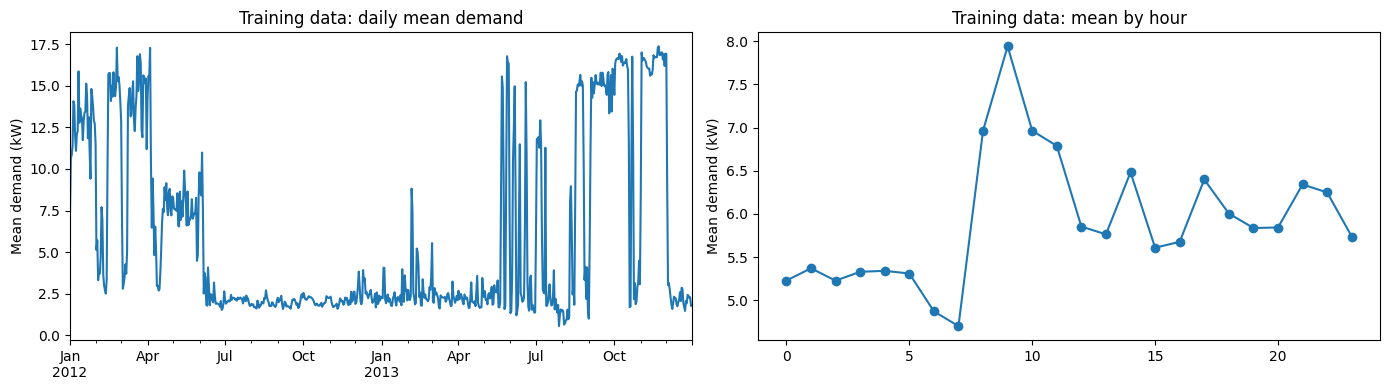

In [8]:
train_series = demand.loc[:"2013-12-31 23:00"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_series.resample("D").mean().plot(ax=axes[0], title="Training data: daily mean demand")
train_series.groupby(train_series.index.hour).mean().plot(
    ax=axes[1], marker="o", title="Training data: mean by hour")
for ax in axes:
    ax.set_ylabel("Mean demand (kW)")
plt.tight_layout()
plt.show()


## 4. Feature engineering and chronological splits
For each midnight forecast, I construct a history containing the previous 168 hourly readings and a target containing the next 24 readings. I encode hour, weekday and annual position with sine and cosine pairs, and include a weekday indicator.

My weekly baseline repeats the same hours from the previous week.

For XGBoost, I create one row per forecast hour with the historical readings, that hour's calendar features and its forecast horizon. The LSTM receives the same historical readings and future calendar information but predicts all 24 targets together.

During validation and testing, each day's history includes readings observed before that day's forecast origin. Model weights remain fixed. This evaluates daily rolling forecasts, rather than a six-month forecast made at a single starting point.


In [9]:
def calendar_features(index):
    return np.column_stack([
        np.sin(2*np.pi*index.hour/24),
        np.cos(2*np.pi*index.hour/24),
        np.sin(2*np.pi*index.dayofweek/7),
        np.cos(2*np.pi*index.dayofweek/7),
        np.sin(2*np.pi*(index.dayofyear-1)/365.25),
        np.cos(2*np.pi*(index.dayofyear-1)/365.25),
        (index.dayofweek < 5).astype(float),
    ]).astype("float32")

values = demand.to_numpy(dtype="float32")
positions = np.array([p for p in range(LOOKBACK, len(values)-HORIZON+1)
                      if demand.index[p].hour == 0])
origins = demand.index[positions]
X_history = np.stack([values[p-LOOKBACK:p] for p in positions])
Y = np.stack([values[p:p+HORIZON] for p in positions])
C = np.stack([calendar_features(demand.index[p:p+HORIZON]) for p in positions])
last_targets = origins + pd.Timedelta(hours=HORIZON-1)
train_mask = last_targets < pd.Timestamp("2014-01-01")
val_mask = (origins >= pd.Timestamp("2014-01-01")) & (last_targets < pd.Timestamp("2014-07-01"))
test_mask = origins >= pd.Timestamp("2014-07-01")
assert train_mask.any() and val_mask.any() and test_mask.any()
assert (train_mask.astype(int)+val_mask.astype(int)+test_mask.astype(int) == 1).all()
assert last_targets[train_mask].max() < origins[val_mask].min()
assert last_targets[val_mask].max() < origins[test_mask].min()

# Weekly baseline: target hour minus 168 hours, always before forecast origin.
weekly_prediction = X_history[:, :HORIZON].copy()
assert np.array_equal(weekly_prediction[0], values[positions[0]-168:positions[0]-144])
for name, mask in [("Train", train_mask), ("Validation", val_mask), ("Test", test_mask)]:
    print(f"{name}: {mask.sum()} forecasts; {origins[mask].min()} to {origins[mask].max()}")

def metrics(truth, prediction):
    error = np.asarray(prediction) - np.asarray(truth)
    denominator = np.abs(truth).sum()
    return {
        "MAE_kW": float(np.abs(error).mean()),
        "RMSE_kW": float(np.sqrt(np.mean(error**2))),
        "WAPE_percent": float(100*np.abs(error).sum()/denominator) if denominator else np.nan,
    }

def tree_features(history, calendar):
    n = len(history)
    return np.concatenate([
        np.repeat(history, HORIZON, axis=0),
        calendar.reshape(n*HORIZON, -1),
        np.tile(np.arange(1, HORIZON+1, dtype="float32")/HORIZON, n)[:, None],
    ], axis=1)

F_train = tree_features(X_history[train_mask], C[train_mask])
F_val = tree_features(X_history[val_mask], C[val_mask])
F_test = tree_features(X_history[test_mask], C[test_mask])
print("Tree training matrix:", F_train.shape)


Train: 724 forecasts; 2012-01-08 00:00:00 to 2013-12-31 00:00:00
Validation: 181 forecasts; 2014-01-01 00:00:00 to 2014-06-30 00:00:00
Test: 184 forecasts; 2014-07-01 00:00:00 to 2014-12-31 00:00:00
Tree training matrix: (17376, 176)


## 5. XGBoost model selection
I compare two tree configurations using validation mean absolute error (MAE). The test period does not influence this choice.

I use a small search to keep computation manageable. The reported time includes both candidate fits. I retain the model fitted on the training period without refitting on validation data.


In [10]:
tree_started = time.perf_counter()
candidates = [
    {"max_depth": 3, "n_estimators": 150},
    {"max_depth": 5, "n_estimators": 250},
]
best_tree, best_tree_config, best_tree_mae = None, None, float("inf")
tree_search = []
for config in candidates:
    candidate = XGBRegressor(
        objective="reg:squarederror", learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        tree_method="hist", n_jobs=2, random_state=SEED, **config)
    candidate.fit(F_train, Y[train_mask].reshape(-1))
    prediction = np.maximum(0, candidate.predict(F_val).reshape(-1, HORIZON))
    score = metrics(Y[val_mask], prediction)["MAE_kW"]
    tree_search.append({**config, "validation_MAE_kW": score})
    if score < best_tree_mae:
        best_tree, best_tree_config, best_tree_mae = candidate, config, score
tree_seconds = time.perf_counter() - tree_started
display(pd.DataFrame(tree_search))
print("Selected configuration:", best_tree_config)


,max_depth,n_estimators,validation_MAE_kW
0,3,150,1.703918
1,5,250,1.610060


Selected configuration: {'max_depth': 5, 'n_estimators': 250}


## 6. LSTM model
I standardise demand using statistics fitted only on the training period. My LSTM encodes a week of historical demand into a 32-dimensional representation. A dense layer combines this representation with the future calendar features to predict 24 values.

I train with mean squared error, gradient clipping and validation-based early stopping. I restore the checkpoint with the lowest validation MAE. I clip predictions from both learned models at zero because electricity demand is non-negative.

This experiment uses one neural architecture and one random seed. I cannot infer the performance of all deep-learning approaches from this comparison.


Epoch 01: validation MAE = 3.8880 kW
Epoch 02: validation MAE = 2.6132 kW
Epoch 03: validation MAE = 1.8455 kW
Epoch 04: validation MAE = 1.8274 kW
Epoch 05: validation MAE = 1.8661 kW
Epoch 06: validation MAE = 1.7557 kW
Epoch 07: validation MAE = 1.7204 kW
Epoch 08: validation MAE = 1.6519 kW
Epoch 09: validation MAE = 1.7545 kW
Epoch 10: validation MAE = 1.6252 kW
Epoch 11: validation MAE = 1.7909 kW
Epoch 12: validation MAE = 1.6231 kW
Epoch 13: validation MAE = 1.6784 kW
Epoch 14: validation MAE = 1.6581 kW
Epoch 15: validation MAE = 1.6117 kW
Epoch 16: validation MAE = 1.6279 kW
Epoch 17: validation MAE = 1.6700 kW
Epoch 18: validation MAE = 1.5351 kW
Epoch 19: validation MAE = 1.6808 kW
Epoch 20: validation MAE = 1.6361 kW
Epoch 21: validation MAE = 1.6369 kW
Epoch 22: validation MAE = 1.5741 kW
Epoch 23: validation MAE = 1.7046 kW
Early stopping.


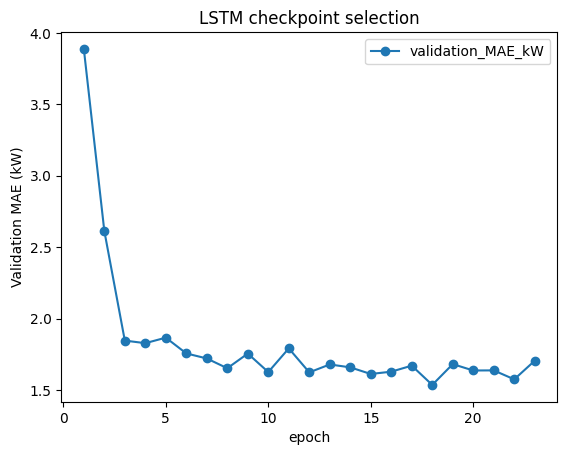

In [11]:
scaler = StandardScaler().fit(train_series.to_numpy().reshape(-1, 1))
def scale(array):
    return scaler.transform(array.reshape(-1, 1)).reshape(array.shape).astype("float32")
def unscale(array):
    return scaler.inverse_transform(array.reshape(-1, 1)).reshape(array.shape)

X_scaled, Y_scaled = scale(X_history), scale(Y)
def dataset(mask):
    return TensorDataset(
        torch.from_numpy(X_scaled[mask, :, None]),
        torch.from_numpy(C[mask].reshape(-1, HORIZON*C.shape[-1])),
        torch.from_numpy(Y_scaled[mask]))

train_loader = DataLoader(dataset(train_mask), batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(dataset(val_mask), batch_size=128, shuffle=False)
test_loader = DataLoader(dataset(test_mask), batch_size=128, shuffle=False)

class DemandLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(32 + HORIZON*C.shape[-1], 64), nn.ReLU(),
            nn.Dropout(0.1), nn.Linear(64, HORIZON))
    def forward(self, history, calendar):
        _, (hidden, _) = self.encoder(history)
        return self.head(torch.cat([hidden[-1], calendar], dim=1))

model = DemandLSTM().to(DEVICE)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

def predict_lstm(loader):
    model.eval()
    batches = []
    with torch.no_grad():
        for history, calendar, _ in loader:
            batches.append(model(history.to(DEVICE), calendar.to(DEVICE)).cpu().numpy())
    return np.maximum(0, unscale(np.concatenate(batches)))

lstm_started = time.perf_counter()
best_state, best_val_mae, stale = None, float("inf"), 0
training_log = []
for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    total_loss = 0.0
    for history, calendar, target in train_loader:
        history, calendar, target = history.to(DEVICE), calendar.to(DEVICE), target.to(DEVICE)
        optimiser.zero_grad()
        loss = loss_fn(model(history, calendar), target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        total_loss += loss.item()*len(history)
    val_mae = metrics(Y[val_mask], predict_lstm(val_loader))["MAE_kW"]
    training_log.append({"epoch": epoch, "train_scaled_MSE": total_loss/train_mask.sum(),
                         "validation_MAE_kW": val_mae})
    print(f"Epoch {epoch:02d}: validation MAE = {val_mae:.4f} kW")
    if val_mae < best_val_mae:
        best_val_mae, stale = val_mae, 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        stale += 1
        if stale >= PATIENCE:
            print("Early stopping.")
            break
assert best_state is not None
model.load_state_dict(best_state)
lstm_seconds = time.perf_counter() - lstm_started
pd.DataFrame(training_log).plot(x="epoch", y="validation_MAE_kW", marker="o",
                              title="LSTM checkpoint selection")
plt.ylabel("Validation MAE (kW)")
plt.show()


## 7. Final evaluation
I select my preferred model by validation MAE before examining test performance. I then report all three pre-specified models on the held-out test period.

I use three error measures:
- **MAE:** mean absolute error, in kW.
- **RMSE:** root mean squared error, in kW; larger errors receive more weight.
- **WAPE:** total absolute error divided by total observed demand, expressed as a percentage.

Lower values indicate better performance. Improvement relative to the weekly baseline is positive when a model reduces MAE and negative when it performs worse. I will not adjust the experiment repeatedly against these test results.


In [12]:
validation_predictions = {
    "Weekly baseline": weekly_prediction[val_mask],
    "XGBoost": np.maximum(0, best_tree.predict(F_val).reshape(-1, HORIZON)),
    "LSTM": predict_lstm(val_loader),
}
selected_model = min(validation_predictions,
    key=lambda name: metrics(Y[val_mask], validation_predictions[name])["MAE_kW"])
print("Model selected on validation:", selected_model)

test_predictions = {
    "Weekly baseline": weekly_prediction[test_mask],
    "XGBoost": np.maximum(0, best_tree.predict(F_test).reshape(-1, HORIZON)),
    "LSTM": predict_lstm(test_loader),
}
rows = []
timings = {"Weekly baseline": 0.0, "XGBoost": tree_seconds, "LSTM": lstm_seconds}
for name, prediction in test_predictions.items():
    assert prediction.shape == Y[test_mask].shape
    assert np.isfinite(prediction).all()
    rows.append({"model": name, **metrics(Y[test_mask], prediction),
                 "validation_MAE_kW": metrics(Y[val_mask], validation_predictions[name])["MAE_kW"],
                 "fit_and_selection_seconds": timings[name]})
results = pd.DataFrame(rows).set_index("model")
baseline_mae = results.loc["Weekly baseline", "MAE_kW"]
results["MAE_improvement_vs_baseline_percent"] = (
    100*(baseline_mae-results["MAE_kW"])/baseline_mae if baseline_mae else np.nan)
display(results.round(4))
print("Positive improvement means lower MAE than the weekly baseline.")
if DEMO_MODE:
    print("REMINDER: these are synthetic-data results.")


Model selected on validation: LSTM


,MAE_kW,RMSE_kW,WAPE_percent,validation_MAE_kW,fit_and_selection_seconds,MAE_improvement_vs_baseline_percent
model,,,,,,
Weekly baseline,2.2345,4.8496,42.4949,2.0889,0.0000,0.0000
XGBoost,1.6755,2.9746,31.8639,1.6101,2.5687,25.0170
LSTM,1.6840,3.0302,32.0268,1.5351,7.8072,24.6337


Positive improvement means lower MAE than the weekly baseline.


## 8. Forecast visualisation and error analysis
I plot the first test week, rather than choosing a particularly successful example. I also examine errors by forecast horizon and month, and inspect the largest daily errors for the model selected on validation.

Horizon 1 represents the interval starting at the forecast origin; horizon 24 represents the final hour in the next-day window.

I examine XGBoost feature importance as a description of model behaviour. These importances are not causal explanations.


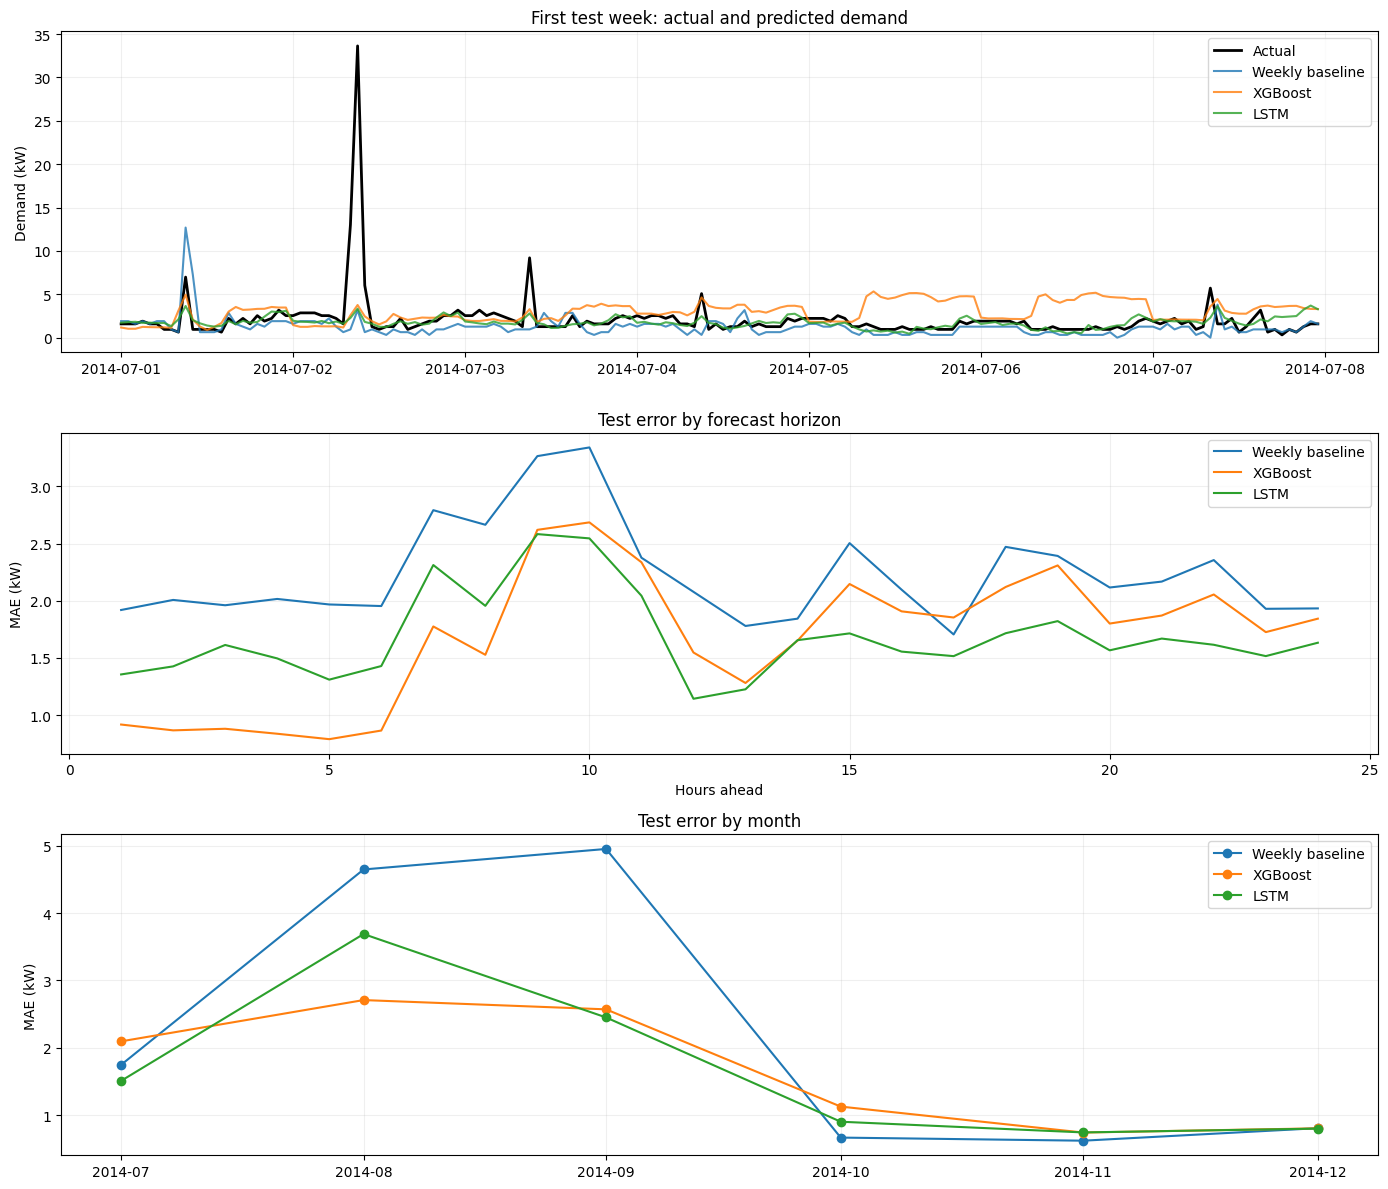

Worst days for the model chosen on validation:


,Weekly baseline,XGBoost,LSTM
2014-08-01,14.025486,14.463254,14.330261
2014-07-11,5.684222,8.968288,8.172591
2014-08-04,9.107974,6.558475,7.585591
2014-09-15,7.349831,7.356043,7.132514
2014-08-06,11.527072,6.315260,6.604996
2014-09-02,6.411273,5.658493,5.844002
2014-07-30,4.917512,5.792013,5.452544
2014-07-10,5.168676,5.123814,5.010149
2014-08-03,16.695747,4.326123,4.927648
2014-09-12,1.956430,3.134756,4.530859


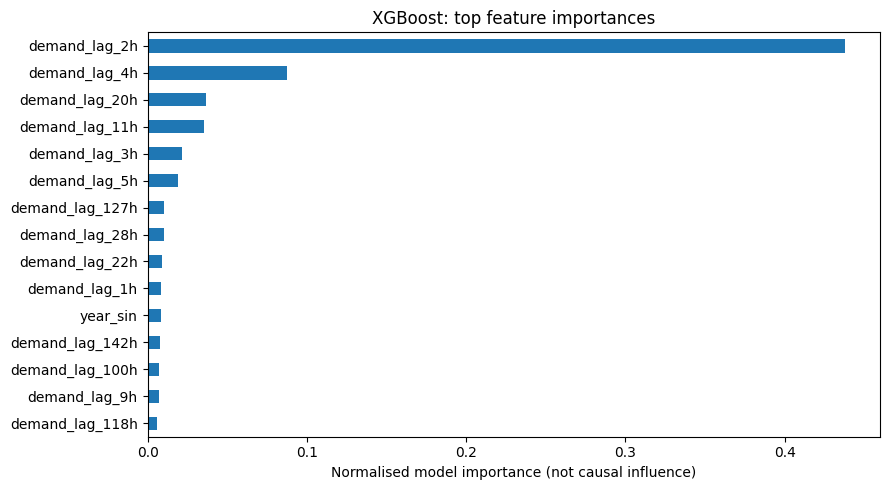

In [13]:
test_origins = origins[test_mask]
truth = Y[test_mask]
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
times = pd.DatetimeIndex([origin + pd.Timedelta(hours=h)
                         for origin in test_origins[:7] for h in range(HORIZON)])
axes[0].plot(times, truth[:7].reshape(-1), color="black", label="Actual", linewidth=2)
for name, pred in test_predictions.items():
    axes[0].plot(times, pred[:7].reshape(-1), label=name, alpha=0.8)
    axes[1].plot(np.arange(1, 25), np.abs(pred-truth).mean(axis=0), label=name)
    errors_by_month = pd.Series(np.abs(pred-truth).mean(axis=1), index=test_origins).resample("MS").mean()
    axes[2].plot(errors_by_month.index, errors_by_month, marker="o", label=name)
axes[0].set_title("First test week: actual and predicted demand")
axes[0].set_ylabel("Demand (kW)")
axes[1].set_title("Test error by forecast horizon")
axes[1].set_xlabel("Hours ahead")
axes[1].set_ylabel("MAE (kW)")
axes[2].set_title("Test error by month")
axes[2].set_ylabel("MAE (kW)")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT / "forecast_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

daily_errors = pd.DataFrame({
    name: np.abs(pred-truth).mean(axis=1) for name, pred in test_predictions.items()
}, index=test_origins)
print("Worst days for the model chosen on validation:")
display(daily_errors.sort_values(selected_model, ascending=False).head(10))

feature_names = (
    [f"demand_lag_{lag}h" for lag in range(LOOKBACK, 0, -1)] +
    ["hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
     "year_sin", "year_cos", "is_weekday", "horizon"])
importance = pd.Series(best_tree.feature_importances_, index=feature_names).nlargest(15)
importance.sort_values().plot.barh(figsize=(9, 5), title="XGBoost: top feature importances")
plt.xlabel("Normalised model importance (not causal influence)")
plt.tight_layout()
plt.show()


## 9. Saving experiment outputs
I save the comparison metrics, training history and timestamped test predictions for further analysis. I also save model parameters, software versions and split dates so I can reproduce the experiment.

The LSTM checkpoint contains its weights and scaling parameters. Reconstructing it also requires the `DemandLSTM` definition in this notebook.


In [14]:
results.to_csv(OUT / "metrics.csv")
pd.DataFrame(training_log).to_csv(OUT / "lstm_training_history.csv", index=False)
forecast_rows = pd.DataFrame({
    "forecast_origin": np.repeat(test_origins.to_numpy(), HORIZON),
    "horizon_hours": np.tile(np.arange(1, HORIZON+1), len(test_origins)),
    "actual_kw": truth.reshape(-1),
    **{name.replace(" ", "_")+"_kw": pred.reshape(-1)
       for name, pred in test_predictions.items()},
})
forecast_rows["target_hour"] = (
    pd.to_datetime(forecast_rows["forecast_origin"]) +
    pd.to_timedelta(forecast_rows["horizon_hours"]-1, unit="h"))
forecast_rows.to_csv(OUT / "test_predictions.csv", index=False)
best_tree.save_model(str(OUT / "xgboost_model.json"))
torch.save({
    "state_dict": {key: value.cpu() for key, value in model.state_dict().items()},
    "scaler_mean": float(scaler.mean_[0]),
    "scaler_scale": float(scaler.scale_[0]),
    "lookback": LOOKBACK, "horizon": HORIZON,
}, OUT / "lstm_checkpoint.pt")
metadata = {
    "seed": SEED, "customer": CLIENT, "synthetic_demo": DEMO_MODE,
    "source": SOURCE_PAGE, "lookback_hours": LOOKBACK, "horizon_hours": HORIZON,
    "selected_on_validation": selected_model, "tree_config": best_tree_config,
    "device": str(DEVICE),
    "versions": {name: importlib.import_module(name).__version__
                 for name in ["numpy", "pandas", "sklearn", "xgboost", "torch"]},
    "splits": {name: {"first_origin": str(origins[mask].min()),
                      "last_origin": str(origins[mask].max()), "days": int(mask.sum())}
               for name, mask in [("train", train_mask), ("validation", val_mask), ("test", test_mask)]},
}
(OUT / "experiment_metadata.json").write_text(json.dumps(metadata, indent=2))
print("Saved:")
for path in sorted(OUT.iterdir()):
    print(path.name)


Saved:
experiment_metadata.json
forecast_comparison.png
lstm_checkpoint.pt
lstm_training_history.csv
metrics.csv
test_predictions.csv
xgboost_model.json


## 10. Discussion and conclusion

### My findings
*I will complete this section after running the real-data experiment.*

- **Model chosen on validation:** [model and validation MAE]
- **Held-out performance:** [test MAE, RMSE and WAPE]
- **Change relative to the weekly baseline:** [percentage improvement or deterioration]
- **Most difficult forecast periods:** [observations supported by the error plots]
- **Accuracy versus computation:** [comparison of errors and measured fitting times]
- **Answer to my research question:** [conclusion supported by these results]

### Limitations
I evaluate one customer, one chronological validation block and six months of test forecasts. I use a small tree search and one LSTM configuration with one seed. The data are historical, and the source's daylight-saving artefacts remain. Training times depend on hardware and include different model-selection procedures; they are not controlled architecture benchmarks. This experiment does not estimate statistical significance, prediction uncertainty or performance on new customers.

### Further work
I plan to evaluate multiple customers, repeat neural training with several seeds and use expanding-window validation. I would also test the contribution of calendar features and different history lengths, investigate source artefacts, and add calibrated prediction intervals. I would reserve fresh evaluation data before using conclusions from this test period to redesign the models.
